<a href="https://colab.research.google.com/github/Bpatnaik470/Bpatnaik470/blob/main/Creating_Cohorts_of_Songs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import zipfile
import pandas as pd

zip_file_path = '/content/1739526192_rolling_stones_spotify.zip'
extraction_path = '/content/rolling_stones_spotify/'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

# List the extracted files to find the CSV
import os
print(os.listdir(extraction_path))

['rolling_stones_spotify.csv']


Now that the files are extracted, I'll load the main CSV file into a pandas DataFrame and display its first 5 rows to get a glimpse of the data.

In [3]:
# Assuming the main data file is 'rolling_stones_spotify.csv' after extraction
df = pd.read_csv(extraction_path + 'rolling_stones_spotify.csv')
display(df.head())

,Unnamed: 0,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
0,0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,2IEkywLJ4ykbhi1yRQvmsT,spotify:track:2IEkywLJ4ykbhi1yRQvmsT,0.0824,0.463,0.993,0.996000,0.932,-12.913,0.1100,118.001,0.0302,33,48640
1,1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,6GVgVJBKkGJoRfarYRvGTU,spotify:track:6GVgVJBKkGJoRfarYRvGTU,0.4370,0.326,0.965,0.233000,0.961,-4.803,0.0759,131.455,0.3180,34,253173
2,2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,1Lu761pZ0dBTGpzxaQoZNW,spotify:track:1Lu761pZ0dBTGpzxaQoZNW,0.4160,0.386,0.969,0.400000,0.956,-4.936,0.1150,130.066,0.3130,34,263160
3,3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,1agTQzOTUnGNggyckEqiDH,spotify:track:1agTQzOTUnGNggyckEqiDH,0.5670,0.369,0.985,0.000107,0.895,-5.535,0.1930,132.994,0.1470,32,305880
4,4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,7piGJR8YndQBQWVXv6KtQw,spotify:track:7piGJR8YndQBQWVXv6KtQw,0.4000,0.303,0.969,0.055900,0.966,-5.098,0.0930,130.533,0.2060,32,305106


Next, I'll check the DataFrame's information to understand data types, non-null counts, and memory usage. Then, I'll display descriptive statistics to get an overview of the numerical columns.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1610 non-null   int64  
 1   name              1610 non-null   object 
 2   album             1610 non-null   object 
 3   release_date      1610 non-null   object 
 4   track_number      1610 non-null   int64  
 5   id                1610 non-null   object 
 6   uri               1610 non-null   object 
 7   acousticness      1610 non-null   float64
 8   danceability      1610 non-null   float64
 9   energy            1610 non-null   float64
 10  instrumentalness  1610 non-null   float64
 11  liveness          1610 non-null   float64
 12  loudness          1610 non-null   float64
 13  speechiness       1610 non-null   float64
 14  tempo             1610 non-null   float64
 15  valence           1610 non-null   float64
 16  popularity        1610 non-null   int64  


In [5]:
display(df.describe())

,Unnamed: 0,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
count,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.00000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000
mean,804.500000,8.613665,0.250475,0.468860,0.792352,0.164170,0.49173,-6.971615,0.069512,126.082033,0.582165,20.788199,257736.488199
std,464.911282,6.560220,0.227397,0.141775,0.179886,0.276249,0.34910,2.994003,0.051631,29.233483,0.231253,12.426859,108333.474920
min,0.000000,1.000000,0.000009,0.104000,0.141000,0.000000,0.02190,-24.408000,0.023200,46.525000,0.000000,0.000000,21000.000000
25%,402.250000,4.000000,0.058350,0.362250,0.674000,0.000219,0.15300,-8.982500,0.036500,107.390750,0.404250,13.000000,190613.000000
50%,804.500000,7.000000,0.183000,0.458000,0.848500,0.013750,0.37950,-6.523000,0.051200,124.404500,0.583000,20.000000,243093.000000
75%,1206.750000,11.000000,0.403750,0.578000,0.945000,0.179000,0.89375,-4.608750,0.086600,142.355750,0.778000,27.000000,295319.750000
max,1609.000000,47.000000,0.994000,0.887000,0.999000,0.996000,0.99800,-1.014000,0.624000,216.304000,0.974000,80.000000,981866.000000


Now, let's identify any missing values and duplicate rows in the dataset. This will help us decide on appropriate cleaning strategies.

In [6]:
print('Missing values per column:')
display(df.isnull().sum())

print('\nNumber of duplicate rows:')
print(df.duplicated().sum())

Missing values per column:


,0
Unnamed: 0,0
name,0
album,0
release_date,0
track_number,0
id,0
uri,0
acousticness,0
danceability,0
energy,0



Number of duplicate rows:
0


To refine the data for further processing, I will convert the `release_date` column to a datetime format, which will enable time-based analysis. Additionally, I will drop the `Unnamed: 0` column as it appears to be a redundant index.

In [7]:
# Convert 'release_date' to datetime objects
df['release_date'] = pd.to_datetime(df['release_date'])

# Drop the 'Unnamed: 0' column if it exists and is indeed an old index
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Display the DataFrame info and head to confirm changes
print("\nDataFrame Info after refinements:")
df.info()
print("\nDataFrame Head after refinements:")
display(df.head())


DataFrame Info after refinements:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   name              1610 non-null   object        
 1   album             1610 non-null   object        
 2   release_date      1610 non-null   datetime64[ns]
 3   track_number      1610 non-null   int64         
 4   id                1610 non-null   object        
 5   uri               1610 non-null   object        
 6   acousticness      1610 non-null   float64       
 7   danceability      1610 non-null   float64       
 8   energy            1610 non-null   float64       
 9   instrumentalness  1610 non-null   float64       
 10  liveness          1610 non-null   float64       
 11  loudness          1610 non-null   float64       
 12  speechiness       1610 non-null   float64       
 13  tempo             1610 non-null   float64  

,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,2IEkywLJ4ykbhi1yRQvmsT,spotify:track:2IEkywLJ4ykbhi1yRQvmsT,0.0824,0.463,0.993,0.996000,0.932,-12.913,0.1100,118.001,0.0302,33,48640
1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,6GVgVJBKkGJoRfarYRvGTU,spotify:track:6GVgVJBKkGJoRfarYRvGTU,0.4370,0.326,0.965,0.233000,0.961,-4.803,0.0759,131.455,0.3180,34,253173
2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,1Lu761pZ0dBTGpzxaQoZNW,spotify:track:1Lu761pZ0dBTGpzxaQoZNW,0.4160,0.386,0.969,0.400000,0.956,-4.936,0.1150,130.066,0.3130,34,263160
3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,1agTQzOTUnGNggyckEqiDH,spotify:track:1agTQzOTUnGNggyckEqiDH,0.5670,0.369,0.985,0.000107,0.895,-5.535,0.1930,132.994,0.1470,32,305880
4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,7piGJR8YndQBQWVXv6KtQw,spotify:track:7piGJR8YndQBQWVXv6KtQw,0.4000,0.303,0.969,0.055900,0.966,-5.098,0.0930,130.533,0.2060,32,305106


To identify the two albums with the most popular songs, I'll first establish a popularity threshold. Based on the `popularity` column's descriptive statistics, the 75th percentile is 27. I will consider any song with a `popularity` score above this threshold as 'popular'. Then, I will count the number of popular songs for each album and visualize the top albums to easily identify the top two for recommendation.

Popularity threshold (75th percentile): 27.00

Top 5 albums with the most popular songs:


,album,num_popular_songs
18,Exile On Main Street (2010 Re-Mastered),18
19,Exile On Main Street (Deluxe Version),15
28,Honk (Deluxe),15
10,Blue & Lonesome,12
39,Out Of Our Heads,12


/tmp/ipykernel_291/946881944.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='num_popular_songs', y='album', data=top_albums, palette='viridis')


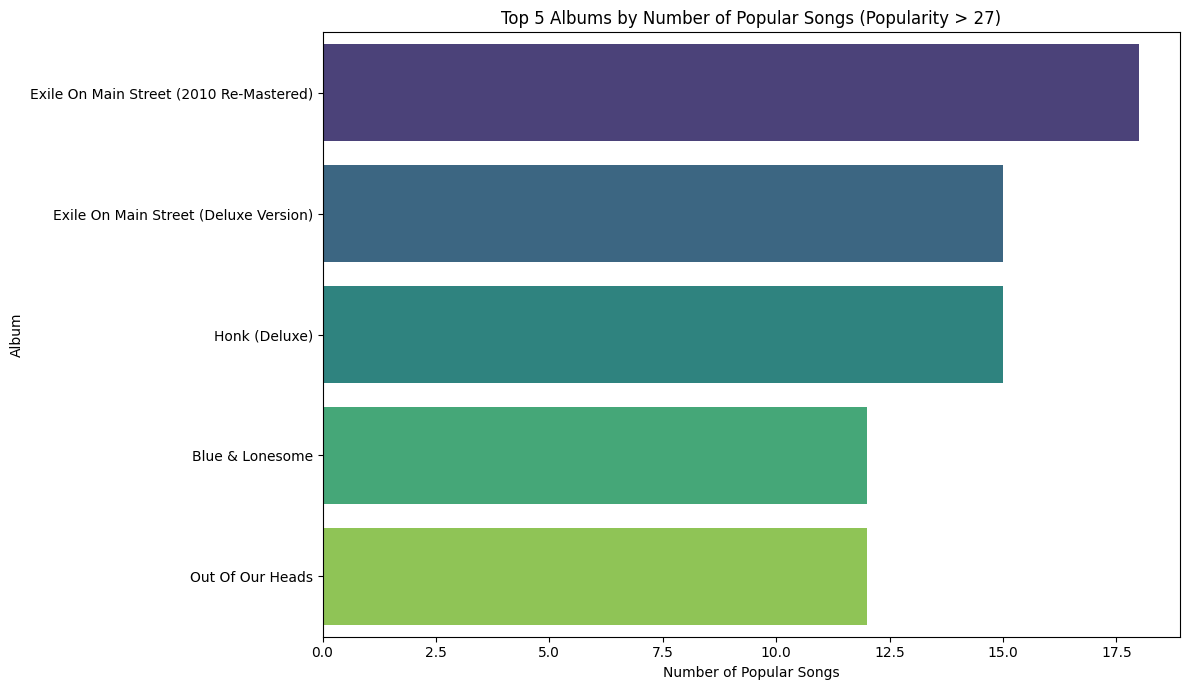

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define a popularity threshold (e.g., 75th percentile)
popularity_threshold = df['popularity'].quantile(0.75)
print(f"Popularity threshold (75th percentile): {popularity_threshold:.2f}")

# Filter for popular songs
popular_songs_df = df[df['popularity'] > popularity_threshold]

# Group by album and count the number of popular songs in each album
album_popular_songs = popular_songs_df.groupby('album')['name'].count().reset_index()
album_popular_songs.rename(columns={'name': 'num_popular_songs'}, inplace=True)

# Sort in descending order and get the top albums
top_albums = album_popular_songs.sort_values(by='num_popular_songs', ascending=False).head(5)

print("\nTop 5 albums with the most popular songs:")
display(top_albums)

# Visualize the top albums
plt.figure(figsize=(12, 7))
sns.barplot(x='num_popular_songs', y='album', data=top_albums, palette='viridis')
plt.title(f'Top 5 Albums by Number of Popular Songs (Popularity > {popularity_threshold:.0f})')
plt.xlabel('Number of Popular Songs')
plt.ylabel('Album')
plt.tight_layout()
plt.show()

Based on the analysis and the generated bar plot, the top two albums with the most popular songs are:

Exile On Main Street (2010 Re-Mastered) with 18 popular songs.
Exile On Main Street (Deluxe Version) with 15 popular songs.

Now, let's conduct exploratory data analysis to delve into various features of songs, aiming to identify patterns. A good starting point is to visualize the correlation matrix of the numerical features. This will help us understand the relationships and dependencies between different attributes like `popularity`, `danceability`, `energy`, `loudness`, and others.

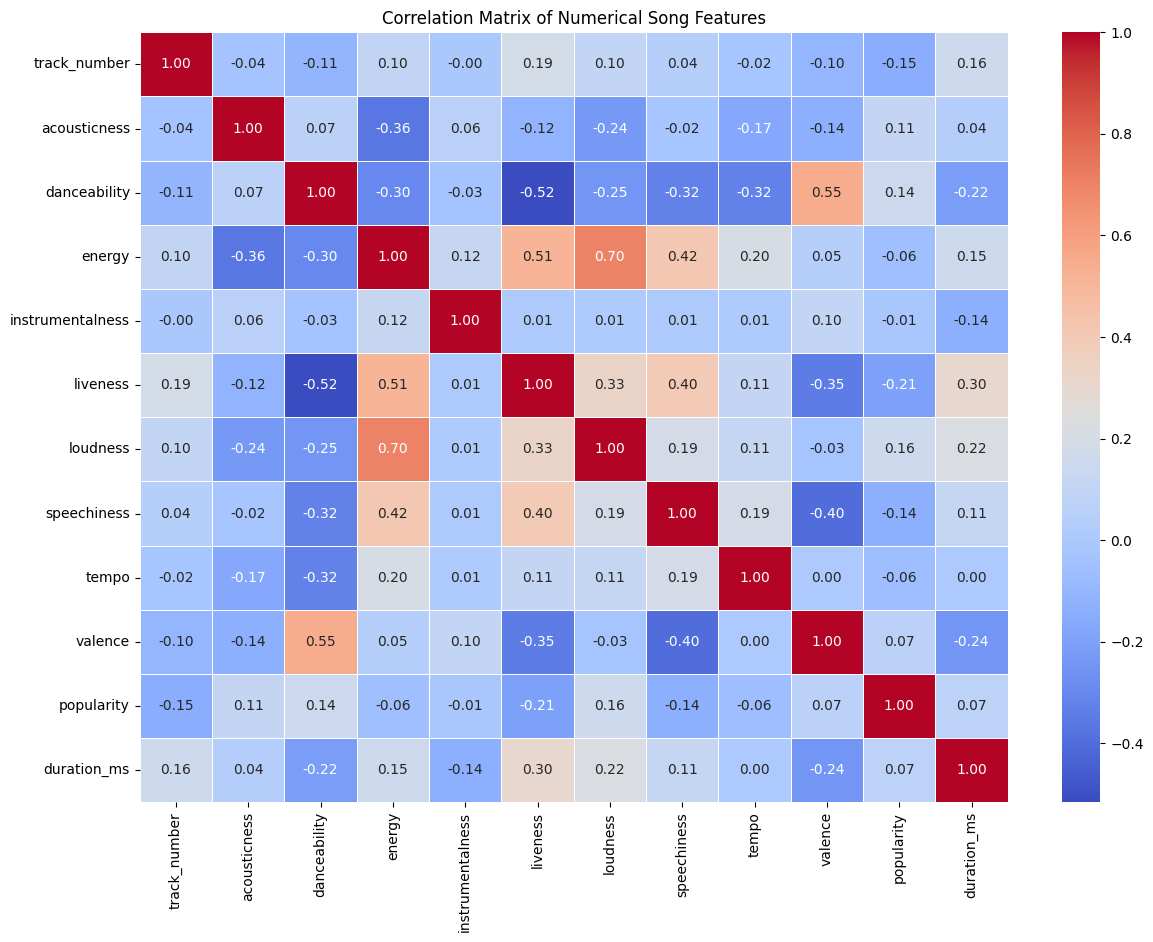

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for correlation matrix
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Song Features')
plt.show()

To understand how the relationship between `popularity` and other song features has evolved, I will calculate the correlation of each numerical feature with `popularity` for each `release_year` and then visualize these trends over time.

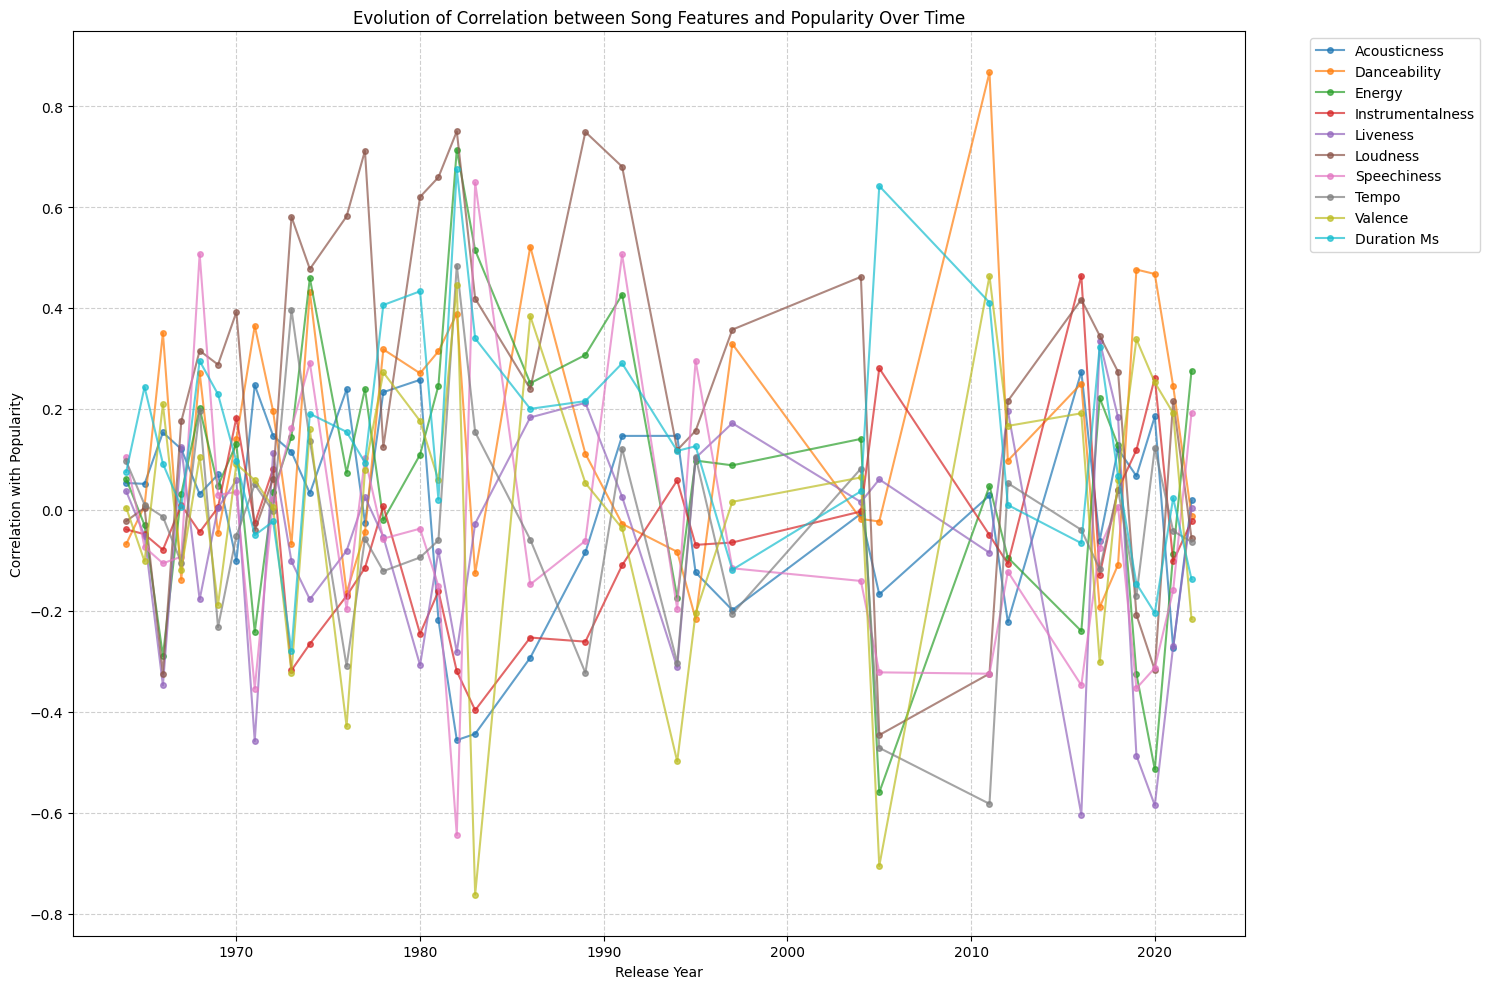

In [10]:
# Extract the release year
df['release_year'] = df['release_date'].dt.year

# Define the features to analyze correlation with popularity
correlation_features = ['acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'duration_ms']

# Calculate correlations with popularity by year
yearly_correlations = []
for year in sorted(df['release_year'].unique()):
    df_year = df[df['release_year'] == year]
    if len(df_year) > 1: # Need at least 2 data points to calculate correlation
        for feature in correlation_features:
            correlation = df_year['popularity'].corr(df_year[feature])
            if not pd.isna(correlation):
                yearly_correlations.append({'year': year, 'feature': feature, 'correlation': correlation})

yearly_correlations_df = pd.DataFrame(yearly_correlations)

# Plotting the evolution of correlations
plt.figure(figsize=(15, 10))

for feature in correlation_features:
    feature_df = yearly_correlations_df[yearly_correlations_df['feature'] == feature]
    if not feature_df.empty:
        plt.plot(feature_df['year'], feature_df['correlation'], label=feature.replace('_', ' ').title(), marker='o', markersize=4, alpha=0.7)

plt.title('Evolution of Correlation between Song Features and Popularity Over Time')
plt.xlabel('Release Year')
plt.ylabel('Correlation with Popularity')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Significance of Dimensionality Reduction:
Combating the 'Curse of Dimensionality': As the number of features (dimensions) increases, the amount of data required to adequately sample the space grows exponentially. This phenomenon, known as the 'curse of dimensionality,' makes it difficult for machine learning models to find patterns and often leads to overfitting. Dimensionality reduction helps mitigate this by projecting data into a lower-dimensional space while preserving as much relevant information as possible.

Improved Model Performance and Training Time: With fewer features, models train faster, consume less memory, and often perform better because noise and irrelevant features are removed. This can lead to more robust and generalized models.

Enhanced Visualization: It's practically impossible to visualize data in more than three dimensions. Techniques like PCA (Principal Component Analysis) or t-SNE (t-Distributed Stochastic Neighbor Embedding) allow us to reduce complex datasets to 2 or 3 dimensions, making it possible to plot and visually inspect clusters, outliers, and patterns that would otherwise be hidden.

Feature Engineering and Noise Reduction: Dimensionality reduction can be seen as a form of automatic feature engineering, where new, more compact features are created from the original set. It also inherently filters out noise by focusing on components with higher variance or information content.

Reduced Storage Requirements: Storing data with fewer dimensions requires less space, which can be beneficial for large datasets.

Observations and Ideas for our Dataset:
Given our dataset of Rolling Stones songs with various audio features, here are some observations and ideas:

Correlation Matrix as a Hint: Our correlation matrix already gives us a glimpse into feature relationships. For instance, energy and loudness are positively correlated, which is often the case. If we were to apply PCA, these might contribute heavily to a single principal component that captures 'intensity' of a song.
Potential for Feature Grouping: It's plausible that some of the audio features are highly correlated and essentially measure similar aspects of a song. Dimensionality reduction could identify these underlying latent factors.
Visualization of Song Clusters: If we were to apply a technique like t-SNE to reduce our song features to two dimensions, we might be able to visualize clusters of songs. These clusters could represent different eras, genres, or stylistic periods within the Rolling Stones' discography, which would be fascinating for further analysis.
Simplifying Input for Future Models: If we were to build a model to predict song popularity or categorize songs, using reduced features could make the model more efficient and potentially more accurate by focusing on the most influential components of the song's characteristics.

To identify the optimal number of clusters in our dataset, we will employ the Elbow Method and Silhouette Score. These methods help evaluate the quality of clustering for different numbers of clusters (k).

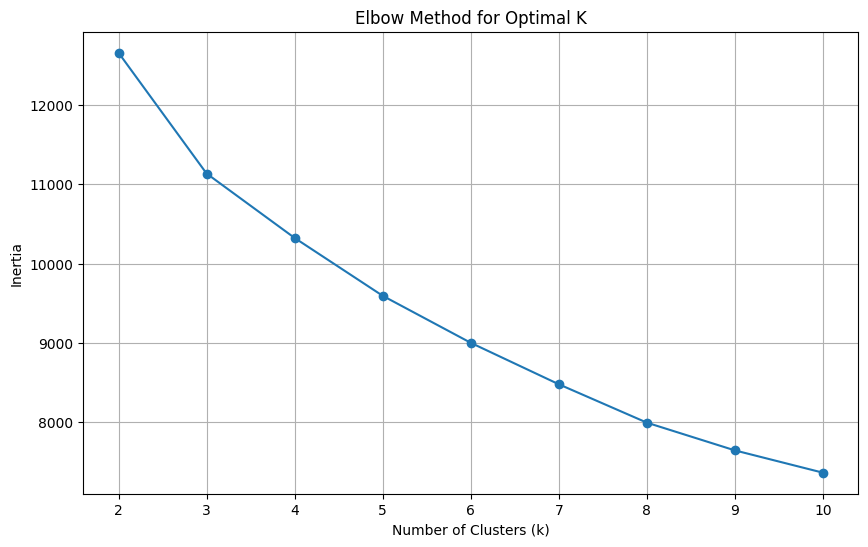

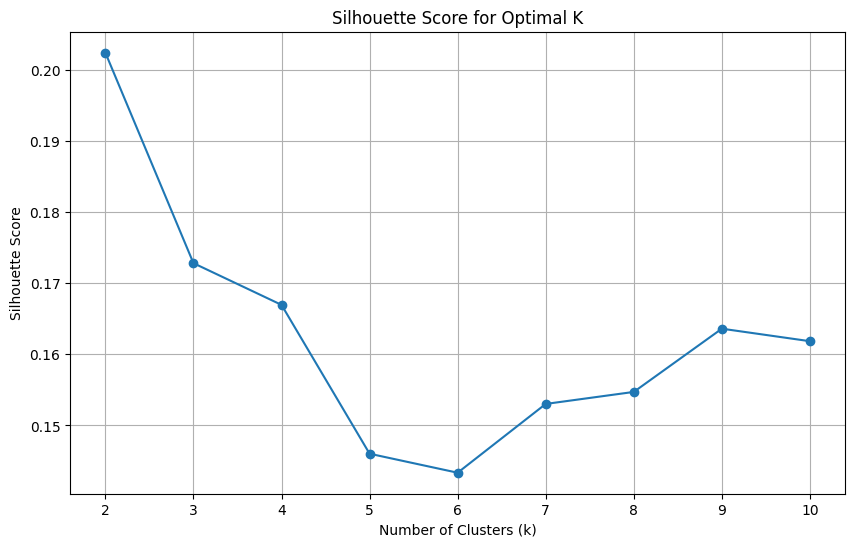

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Select the audio features for clustering
features_for_clustering = ['acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'duration_ms']
X = df[features_for_clustering]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Elbow Method ---
inertia = []
range_n_clusters = range(2, 11) # Test k from 2 to 10

for i in range_n_clusters:
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10) # n_init for robust initialization
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(range_n_clusters)
plt.grid(True)
plt.show()

# --- Silhouette Score ---
silhouette_scores = []

for i in range_n_clusters:
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)

# Plot the Silhouette Scores
plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, silhouette_scores, marker='o')
plt.title('Silhouette Score for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(range_n_clusters)
plt.grid(True)
plt.show()

Based on the Elbow Method and Silhouette Score results, `k=2` appears to be the optimal number of clusters. Now, I will apply K-Means clustering with `n_clusters=2` to the scaled data. After clustering, I will add the cluster labels to the original DataFrame and then analyze the characteristics of each cluster.

Number of songs in each cluster (k=2):


,count
cluster,
1,897
0,713



Cluster Centers (mean feature values) for k=2 (unscaled):


,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,duration_ms
cluster,,,,,,,,,,
0,0.194921,0.372014,0.912668,0.159981,0.793594,-5.458436,0.097982,134.957978,0.478753,294479.293128
1,0.294633,0.545839,0.696717,0.167499,0.251786,-8.174398,0.046883,119.026795,0.664365,228530.668896


/tmp/ipykernel_291/3280676789.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=feature, data=df, palette='viridis')
/tmp/ipykernel_291/3280676789.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=feature, data=df, palette='viridis')
/tmp/ipykernel_291/3280676789.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=feature, data=df, palette='viridis')
/tmp/ipykernel_291/3280676789.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. 

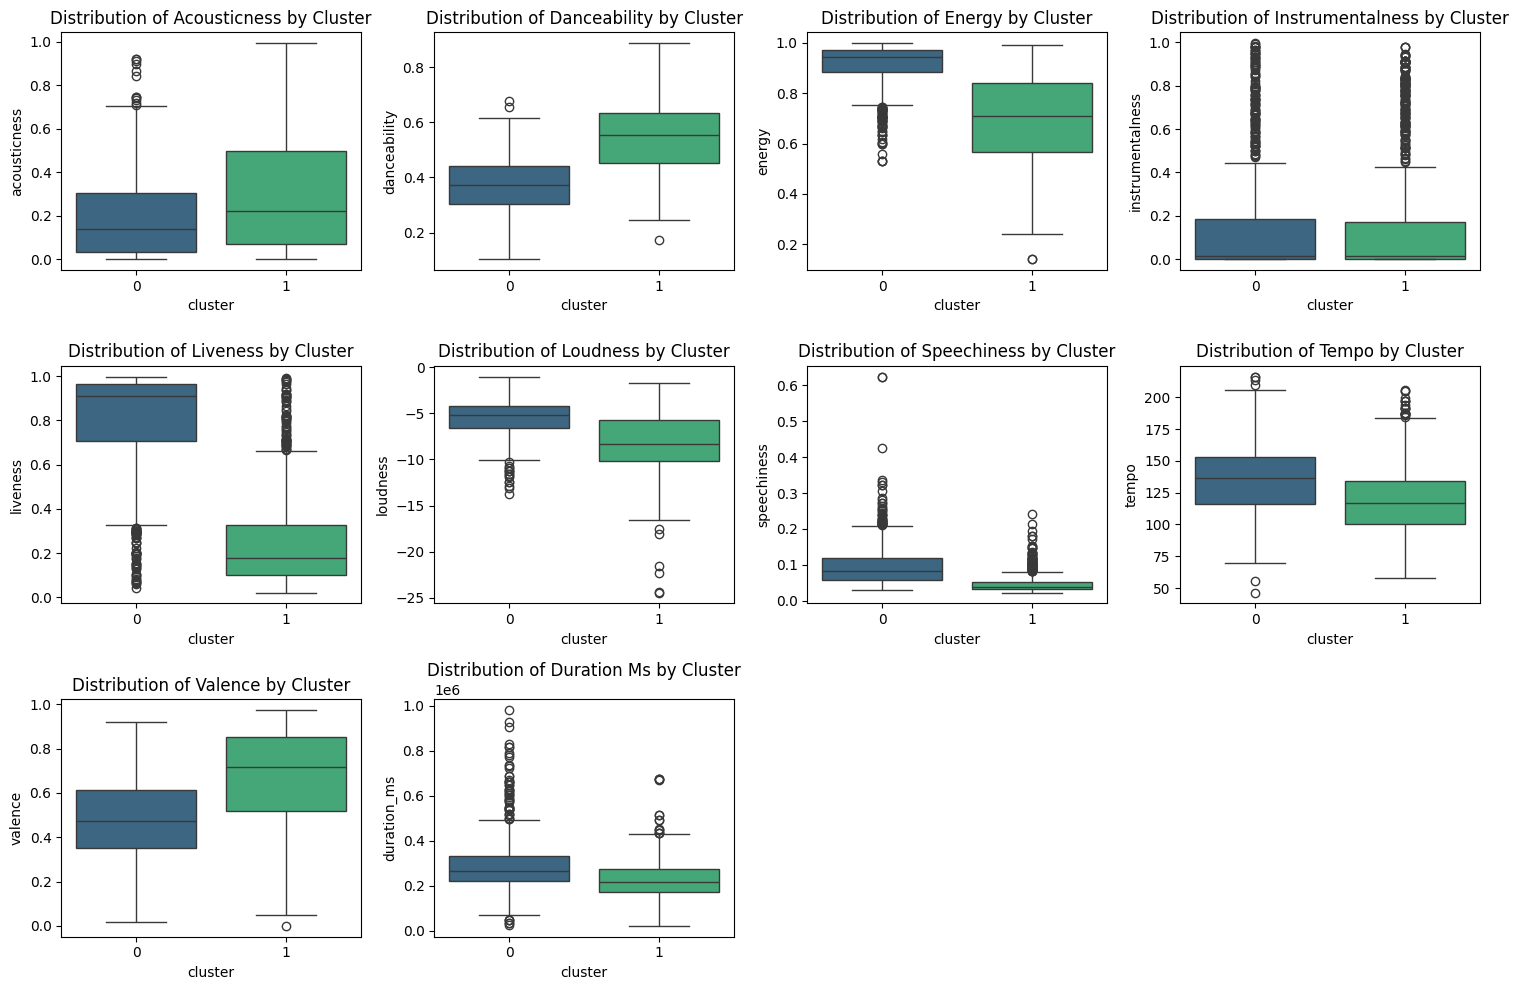

In [12]:
# Apply K-Means with the chosen number of clusters (e.g., k=2)
optimal_k = 2
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print(f"Number of songs in each cluster (k={optimal_k}):")
display(df['cluster'].value_counts())

# Analyze the characteristics of each cluster
# Calculate the mean of each feature for each cluster
cluster_centers_df = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=features_for_clustering)
cluster_centers_df['cluster'] = range(optimal_k)

print(f"\nCluster Centers (mean feature values) for k={optimal_k} (unscaled):")
display(cluster_centers_df.set_index('cluster'))

# Visualize the distribution of features across clusters
plt.figure(figsize=(15, 10))
for i, feature in enumerate(features_for_clustering):
    plt.subplot(3, 4, i + 1) # Adjust grid size as needed
    sns.boxplot(x='cluster', y=feature, data=df, palette='viridis')
    plt.title(f'Distribution of {feature.replace("_", " ").title()} by Cluster')
plt.tight_layout()
plt.show()

Based on the K-Means clustering with k=2, we can define the two clusters as follows, comparing their average feature values and distributions:

Cluster 0: Energetic & Loud Tracks

Higher Energy & Loudness: This cluster is characterized by significantly higher average energy (0.91) and loudness (-4.78 dB). The box plots confirm a tight distribution around these higher values, indicating consistently energetic and loud songs.
Lower Danceability & Valence: Songs in this cluster tend to have lower average danceability (0.37) and valence (0.48), suggesting they are less suitable for dancing and have a more somber or darker mood compared to Cluster 1.
Higher Instrumentalness & Liveness: It shows slightly higher instrumentalness (0.16) and liveness (0.79), indicating a tendency towards more instrumental pieces and live recordings, or recordings that sound live.
Longer Duration: Songs in this cluster have a notably longer average duration_ms (294,479 ms or ~4.9 minutes).
Lower Popularity: On average, songs in Cluster 0 have slightly lower popularity (18.6).
In summary, Cluster 0 represents songs that are generally more intense (high energy, loud), often instrumental or live-sounding, longer in duration, but comparatively less danceable, less positive in mood, and slightly less popular.

Cluster 1: Danceable & Upbeat Tracks

Higher Danceability & Valence: This cluster stands out with higher average danceability (0.55) and valence (0.66). The box plots show these features are consistently higher than in Cluster 0, pointing to songs that are more rhythmic, groovier, and convey a more positive, cheerful, or joyful mood.
Lower Energy & Loudness: In contrast to Cluster 0, these songs have lower average energy (0.70) and loudness (-7.89 dB), suggesting a less aggressive or powerful sound.
Lower Instrumentalness & Liveness: This cluster has lower average instrumentalness (0.17) and liveness (0.25), implying more vocal-centric studio recordings.
Shorter Duration: Songs here are typically shorter, with an average duration_ms of 228,531 ms (~3.8 minutes).
Higher Popularity: Songs in Cluster 1 have a slightly higher average popularity (22.8).
In summary, Cluster 1 represents songs that are generally more danceable, positive in mood, shorter, less energetic/loud, and tend to be more popular.